In [1]:
import uproot
import matplotlib.pyplot as plt
import numpy as np

from mpl_toolkits.axes_grid1 import make_axes_locatable

from mpl_toolkits.mplot3d import Axes3D

In [2]:
file = uproot.open("phsp.root")
tree = file["phsp"]
tree.keys()

['x_mm', 'y_mm', 'z_mm', 'ux', 'uy', 'uz', 'E_MeV', 't_ns', 'w', 'pdg']

In [3]:
x = tree["x_mm"].array(library="np")
y = tree["y_mm"].array(library="np")
z = tree["z_mm"].array(library="np")
E = tree["E_MeV"].array(library="np")
t = tree["t_ns"].array(library="np")
pdg = tree["pdg"].array(library="np")

ux = tree["ux"].array(library="np")
uy = tree["uy"].array(library="np")
uz = tree["uz"].array(library="np")

In [4]:
colormp="jet"
cm = plt.get_cmap(colormp)

In [5]:
xmin, xmax = -20, 20
ymin, ymax = -20, 20
binsx, binsy = 80, 80

hist, xedges, yedges = np.histogram2d(
    x, y,
    bins=[binsx, binsy],
    range=[[xmin, xmax], [ymin, ymax]],
    #weights=E
)

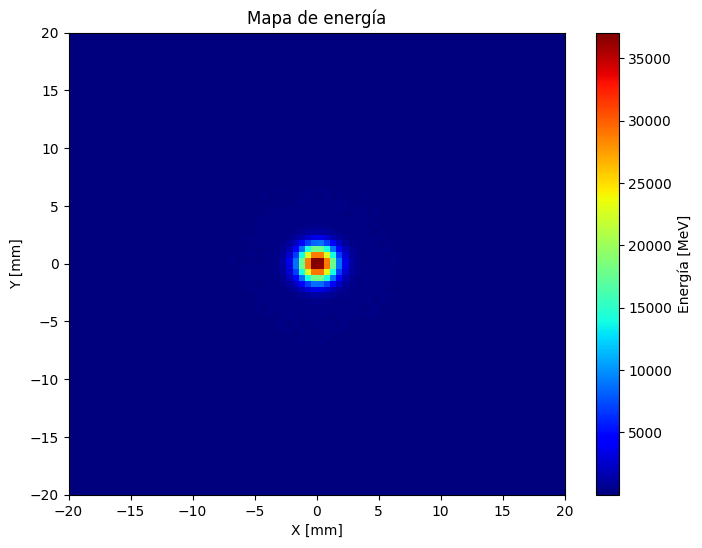

In [6]:
plt.figure(figsize=(8, 6))
plt.imshow(
    hist.T,                          # transponer para que los ejes coincidan
    origin="lower",
    extent=[xmin, xmax, ymin, ymax], # definir ejes en mm
    cmap="jet",
    aspect="auto"
)
plt.colorbar(label="Energía [MeV]")
plt.xlabel("X [mm]")
plt.ylabel("Y [mm]")
plt.title("Mapa de energía")
plt.savefig("MapaEnergia.png", dpi=300)
plt.show()

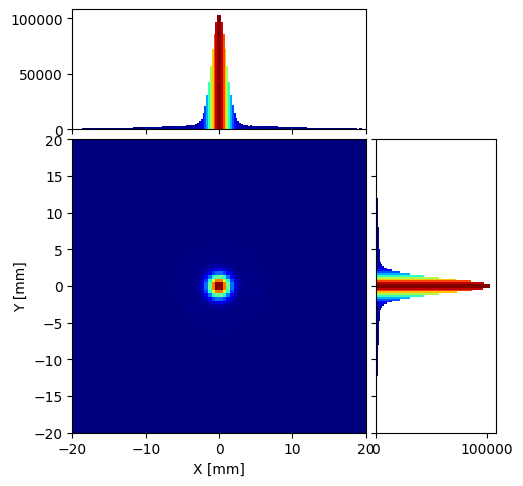

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))

# the scatter plot:
ax.imshow(
    hist.T,                          # transponer para que los ejes coincidan
    origin="lower",
    extent=[xmin, xmax, ymin, ymax], # definir ejes en mm
    cmap=colormp,
    aspect="auto"
)
plt.xlabel("X [mm]")
plt.ylabel("Y [mm]")

# Set aspect of the main Axes.
ax.set_aspect(1.)

# create new Axes on the right and on the top of the current Axes
divider = make_axes_locatable(ax)
# below height and pad are in inches
ax_histx = divider.append_axes("top", 1.2, pad=0.1, sharex=ax)
ax_histy = divider.append_axes("right", 1.2, pad=0.1, sharey=ax)

# make some labels invisible
ax_histx.xaxis.set_tick_params(labelbottom=False)
ax_histy.yaxis.set_tick_params(labelleft=False)

# now determine nice limits by hand:
binwidth = 0.25
xymax = max(np.max(np.abs(x)), np.max(np.abs(y)))
lim = (int(xymax/binwidth) + 1)*binwidth

bins = np.arange(-lim, lim + binwidth, binwidth)

n, bins, patches = ax_histx.hist(x,bins=bins)
# To normalize your values
col = (n-n.min())/(n.max()-n.min())
for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', cm(c))

n, bins, patches = ax_histy.hist(y, bins=bins, orientation='horizontal')
# To normalize your values
col = (n-n.min())/(n.max()-n.min())
for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', cm(c))

plt.show()

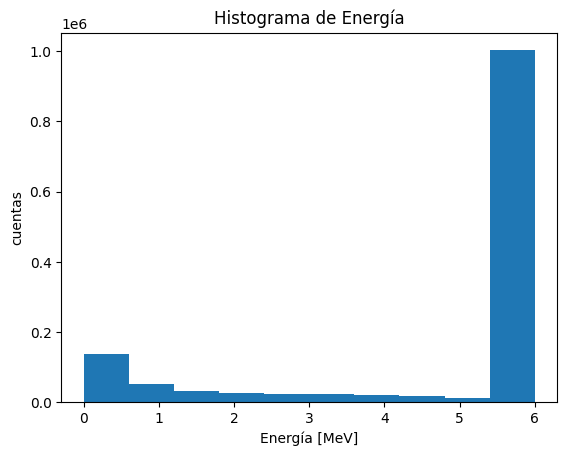

In [21]:
plt.hist(E,bins=10)
plt.xlabel("Energía [MeV]")
plt.ylabel("cuentas")
plt.title("Histograma de Energía")
plt.show()

In [30]:
pdg_leptons = {
    11:  "e-",
    -11: "e+",
    12:  "nu_e",
    -12: "anti_nu_e",
    13:  "mu-",
    -13: "mu+",
    14:  "nu_mu",
    -14: "anti_nu_mu",
    15:  "tau-",
    -15: "tau+",
    16:  "nu_tau",
    -16: "anti_nu_tau"
    21 : "gluon"
    22 : "foton" 
}

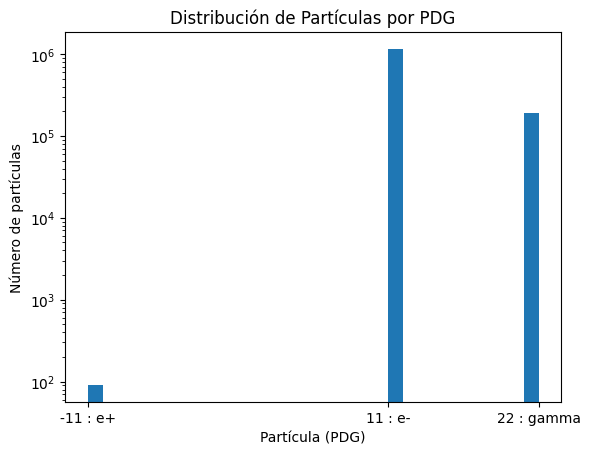

In [40]:
fig, ax = plt.subplots()
ax.hist(pdg,bins=30)
ax.set_yscale('log') 
plt.xticks([-11,11,22],["-11 : e+","11 : e-","22 : gamma"])
plt.xlabel("Partícula (PDG)")
plt.ylabel("Número de partículas")
plt.title("Distribución de Partículas por PDG")
plt.show()

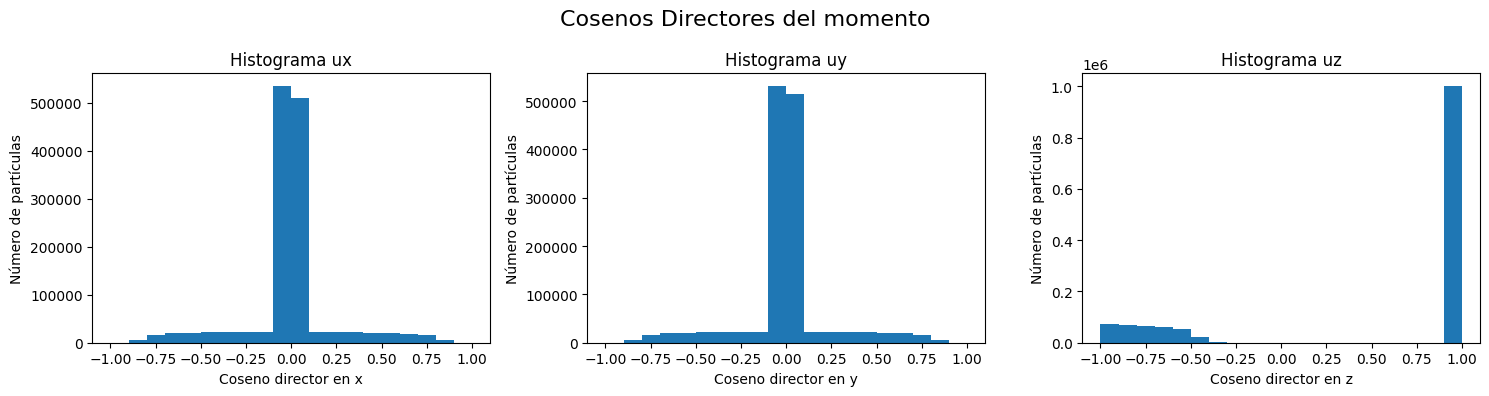

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # 1 fila, 3 columnas

# ux
axes[0].hist(ux, bins=20)
axes[0].set_xlabel('Coseno director en x')
axes[0].set_ylabel('Número de partículas')
axes[0].set_title('Histograma ux')

# uy
axes[1].hist(uy, bins=20)
axes[1].set_xlabel('Coseno director en y')
axes[1].set_ylabel('Número de partículas')
axes[1].set_title('Histograma uy')

# uz
axes[2].hist(uz, bins=20)
axes[2].set_xlabel('Coseno director en z')
axes[2].set_ylabel('Número de partículas')
axes[2].set_title('Histograma uz')
fig.suptitle("Cosenos Directores del momento", fontsize=16)
plt.tight_layout()
plt.show()